# Source normalization: flux vs. rate

PR 1 splits `Source` into two families, `FarFieldSource` and `NearFieldSource`,
and gives every source a common `simulated_rate()` so that `Simulator` can mix
both families in one run. This notebook is a companion to that refactor: it
shows what changed, and -- just as importantly -- what did **not** change for
the runs the tutorials already do.

Remember we live in flatland: fluxes are per unit *length* per time
(`1/cm/s`, not `1/cm2/s`), and the detector's "throwing plane" -- the line
photons are launched from -- is a segment of length `2 x surrounding_circle_radius`.

## 1. Why two kinds of normalization

A source at effectively infinite distance -- a point on the sky, or the
isotropic sky itself -- is naturally described by a **flux**, in `1/cm/s`.
The photons arrive as a parallel beam, and the only geometric question the
detector asks is "how wide a slice of that beam do I intercept?" That slice
is the throwing plane, of size `2a` (`a` = the surrounding-circle radius), so
the rate of photons the detector actually has to deal with is just
`flux * 2a`. This is exactly what the existing tutorials already do with
`PointSource` and `IsotropicSource`.

A source sitting right next to the detector -- or inside it, like an
activation line or a calibration source bolted to the frame -- doesn't have a
meaningful "flux at the detector" at all. Its photons don't arrive as a
parallel beam; they fan out from a point close enough that direction and
distance both matter. What describes such a source is a **total emission
rate**, in `1/s` (photons per second, integrated over its full 2 pi of emission
angle), together with a geometric acceptance -- what fraction of that emission
happens to point at the detector.

Two different physical quantities, `1/cm/s` and `1/s`, and neither converts
into the other without knowing the detector's geometry. That's the whole
reason PR 1 exists: before this refactor, `Simulator` could only normalize
and mix sources by flux, so there was no way to put an instrumental
background source (no sensible flux) in the same run as an astrophysical one
(no sensible rate) without one of them lying about its units. The fix is a
common currency both families can be converted to -- see below.

## 2. `simulated_rate()` is the common currency

Every source, far-field or near-field, now exposes

```python
source.simulated_rate(detector, pose=None) -> Quantity  # 1/s
```

the expected rate of photons **launched at the detector's throwing plane**,
before any trigger condition and before occultation (occultation doesn't
exist yet -- it arrives with the inertial simulator in a later PR).

For a `FarFieldSource` this is uniformly

```
simulated_rate = flux * detector.throwing_plane_size
```

Let's check that numerically: build a detector and a `PointSource`, then
compare `simulated_rate()` against the same product computed by hand from the
source's `flux` and the detector's geometry.

In [1]:
from gammaraytoys import ToyTracker2D
import astropy.units as u
import numpy as np

np.random.seed(0)

# The same COSIta-like detector used in the tutorials.
det = ToyTracker2D(material = 'Ge',
                   layer_length = 16*u.cm,
                   layer_positions = [0,5,10, 20,25,30, 40,45,50, 60,65,70]*u.mm,
                   layer_thickness = 5*u.mm,
                   energy_resolution = 0.01,
                   energy_threshold = 20*u.keV)

print(f"throwing_plane_size = {det.throwing_plane_size:.4f}")

throwing_plane_size = 17.4642 cm


In [2]:
from gammaraytoys.sims import PointSource, PowerLawSpectrum

spectrum = PowerLawSpectrum(index = -2, min_energy = 0.2*u.MeV, max_energy = 10*u.MeV)
flux = 1e-3 / u.cm / u.s

crab_like = PointSource(offaxis_angle = 30*u.deg, spectrum = spectrum, flux = flux)

rate_from_method = crab_like.simulated_rate(det)
rate_by_hand = flux * det.throwing_plane_size

print(f"simulated_rate()      = {rate_from_method.to(1/u.s):.6f}")
print(f"flux * throwing_plane = {rate_by_hand.to(1/u.s):.6f}")
print(f"equal: {np.isclose(rate_from_method.to_value(1/u.s), rate_by_hand.to_value(1/u.s))}")

simulated_rate()      = 0.017464 1 / s
flux * throwing_plane = 0.017464 1 / s
equal: True


They match exactly, as they must -- `FarFieldSource.simulated_rate()` is
nothing but that product. The point of naming it a *rate* rather than
leaving it as a flux is that a rate is something you can **sum** across
sources that don't share a common flux unit. Summing fluxes only makes sense
when every source is far-field; summing rates works no matter what family
each source belongs to. That's what lets a single `Simulator` run mix a
sky source and an instrumental one, in section 5 below.

## 3. The refactor changes nothing for existing far-field runs

This is the single most important property for a reviewer to check: for a
run that only has far-field sources (i.e. every run the tutorials do today),
the new rate-based `nsim` must come out **identical** to the old
flux-based formula tutorial 02 uses:

```python
nsim = round((flux * duration * det.throwing_plane_size).to_value(''))
```

`Simulator._standardize_termination` now computes `nsim = round((total_simulated_rate *
duration).to_value(''))`, with `total_simulated_rate = simulated_rate()` summed over
sources. For a far-field-only run `simulated_rate() == flux *
throwing_plane_size` exactly (section 2), so the two formulas are the same
formula, just factored differently. Let's check it across a few durations,
spanning small counts to large ones.

In [3]:
from gammaraytoys.sims import SimpleTraditionalReconstructor, Simulator

reco = SimpleTraditionalReconstructor()
sim = Simulator(det, crab_like, reco)

for duration in [500, 5_000, 500_000] * u.s:
    old_formula_nsim = round((flux * duration * det.throwing_plane_size).to_value(''))
    new_nsim, _, _ = sim._standardize_termination(duration = duration)

    print(f"duration = {duration:>10}   "
          f"old nsim = {old_formula_nsim:>7}   new nsim = {new_nsim:>7}   "
          f"match: {old_formula_nsim == new_nsim}")

duration =      500.0 s   old nsim =       9   new nsim =       9   match: True
duration =     5000.0 s   old nsim =      87   new nsim =      87   match: True
duration =   500000.0 s   old nsim =    8732   new nsim =    8732   match: True


Same numbers, every time, at every scale. `Simulator.total_simulated_rate`
is the one general quantity that replaces the old flux-based formula: the
sum of `simulated_rate()` over every source in the run, far-field or
near-field alike. There is no separate `total_flux` any more -- a flux only
means something for a far-field source, so PR 1 drops it in favor of the
single quantity that works for every source family (see section 5).

## 4. Spectra for both families

`Source.plot_spectrum()` (and `diff_flux`, `integrate_flux`,
`discretize_spectrum`) are all written in terms of a single polymorphic
`normalization` property, rather than `flux` directly. For a `FarFieldSource`,
`normalization` is `flux` (`1/cm/s`); for a `NearFieldSource`, it's `rate`
(`1/s`). That's what lets the exact same plotting code produce the right
y-axis units for either family, with no special-casing.

First, the far-field source from above:

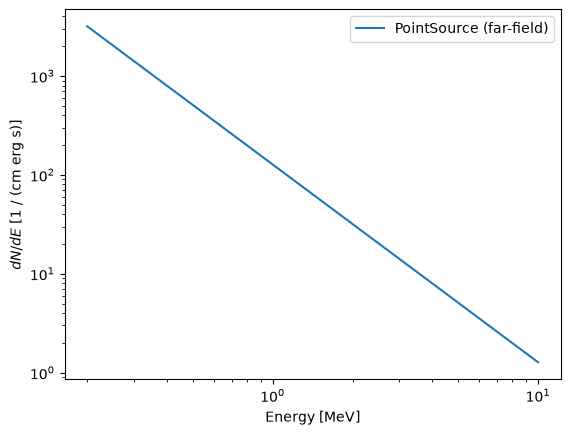

In [4]:
ax = crab_like.plot_spectrum(label = 'PointSource (far-field)')
ax.legend();

Now let's build the smallest possible `NearFieldSource` to see the other
half of that polymorphism in action. This is **not** the real near-field
source PR 4 adds (`NearPointSource`, which places itself at a detector-frame
position and works out its own geometric acceptance from the distance to the
surrounding circle -- see section 5.4 of the design doc). It's a stub, just
to show the extension point `simulated_rate()` and `normalization` create:
any subclass that supplies a `rate`, a `spectrum`, `simulated_rate()` and
`random_photon()` slots straight into `Simulator` and into every one of the
`Source` base class's spectrum helpers, unchanged.

Here every emitted photon is placed well inside the detector's surrounding
circle, so (per the inside-the-circle case PR 4 will formalize) every photon
that's emitted also reaches the throwing circle: `simulated_rate() == rate`,
no geometric discount at all.

rate:                        0.005 1 / s
normalization (= rate here): 0.005 1 / s


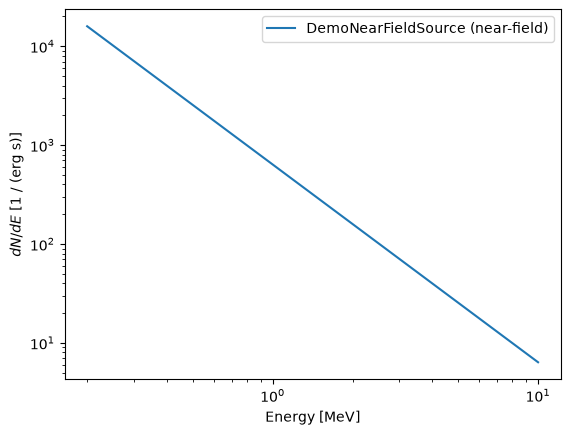

In [5]:
from gammaraytoys.sims import NearFieldSource
from gammaraytoys import Photon
from gammaraytoys.coordinates import Cartesian2D

class DemoNearFieldSource(NearFieldSource):
    """Toy near-field source: an isotropic emitter at a fixed detector-frame
    position, well inside the surrounding circle. Only here to demonstrate
    the extension point -- PR 4 adds the real `NearPointSource`."""

    def __init__(self, position, rate, spectrum):
        self.position = position
        self._rate = rate
        self._spectrum = spectrum

    @property
    def rate(self):
        return self._rate

    @property
    def spectrum(self):
        return self._spectrum

    def simulated_rate(self, detector, pose = None):
        # Fully inside the surrounding circle -> every emitted photon reaches
        # the throwing circle (the f = 1 branch of NearPointSource, PR 4).
        return self.rate

    def random_photon(self, detector, pose = None):
        return Photon(position = self.position,
                      direction = np.random.uniform(0, 360)*u.deg,
                      energy = self.spectrum.random_energy())


calibration_source = DemoNearFieldSource(position = Cartesian2D(0*u.cm, 3.5*u.cm),
                                         rate = 5e-3/u.s,
                                         spectrum = spectrum)

# Note there is no `calibration_source.flux` -- a NearFieldSource has no flux
# at all (see PR 1's Source / FarFieldSource / NearFieldSource split).
print(f"rate:                        {calibration_source.rate}")
print(f"normalization (= rate here): {calibration_source.normalization}")

ax = calibration_source.plot_spectrum(label = 'DemoNearFieldSource (near-field)')
ax.legend();

Same spectrum shape, same plotting call -- but the y axis switched from
`1/(erg cm s)` to `1/(erg s)` automatically, because `plot_spectrum` derived
its units from `self.normalization`, and `normalization` resolved
differently for the two families. Nothing in `Source.plot_spectrum` knows
about "far-field" or "near-field"; it only knows about `normalization`.

## 5. Mixing both in one `Simulator`

This is the scenario the whole refactor exists for: a sky source (flux
normalized) and an instrumental source (rate normalized) thrown into the
same `Simulator`, at the same time, selected event-by-event with probability
proportional to their `simulated_rate()`.

In [6]:
mixed_sim = Simulator(det, [crab_like, calibration_source], reco)

expected_total = crab_like.simulated_rate(det) + calibration_source.simulated_rate(det)

print(f"crab_like.simulated_rate()          = {crab_like.simulated_rate(det).to(1/u.s):.6f}")
print(f"calibration_source.simulated_rate() = {calibration_source.simulated_rate(det).to(1/u.s):.6f}")
print(f"mixed_sim.total_simulated_rate      = {mixed_sim.total_simulated_rate.to(1/u.s):.6f}")
print(f"sum of the two simulated_rate()s    = {expected_total.to(1/u.s):.6f}")

crab_like.simulated_rate()          = 0.017464 1 / s
calibration_source.simulated_rate() = 0.005000 1 / s
mixed_sim.total_simulated_rate      = 0.022464 1 / s
sum of the two simulated_rate()s    = 0.022464 1 / s


There is no `total_flux` for this run: a single flux never described a mix
that includes a near-field source in the first place, so `Simulator`
doesn't offer one any more -- `total_simulated_rate` is the one quantity
that always works, for far-field and near-field sources alike.

Now let's actually run it. This time we stop on `ntrig` -- a target number
of *triggered* events -- rather than a raw photon count, since the point is
to see what the mixed source looks like once reconstructed. We bin the
result with `run_binned` the same way the Compton telescope tutorials do
(see `docs/tutorials/compton_telescopes/02-measured_energy_n_CDS.ipynb`),
and look at it two ways: the measured-energy projection (`Em`), and the
Compton Data Space (`Phi` vs. `Psi`).

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 1/1000 [00:01<18:51,  1.13s/it]

  0%|          | 2/1000 [00:01<12:26,  1.34it/s]

  0%|          | 3/1000 [00:02<13:33,  1.23it/s]

  0%|          | 4/1000 [00:03<12:05,  1.37it/s]

...

100%|█████████▉| 998/1000 [08:15<00:01,  1.64it/s]

100%|█████████▉| 999/1000 [08:16<00:00,  1.03it/s]

100%|██████████| 1000/1000 [08:18<00:00,  1.08s/it]

100%|██████████| 1000/1000 [08:18<00:00,  2.01it/s]

We simulated 9.3e+06 s (209985 events) and detected 1000
relative rate weights (crab_like, calibration_source): [0.777 0.223]


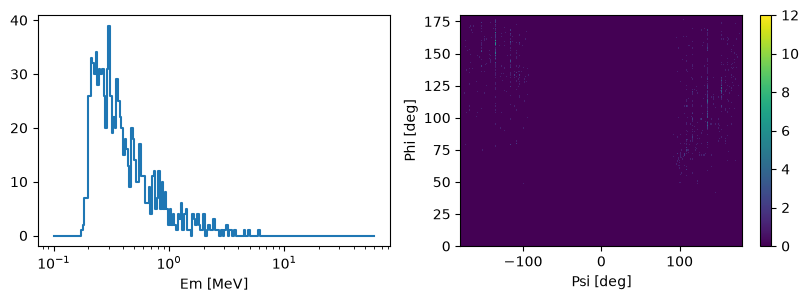

In [7]:
import matplotlib.pyplot as plt

ntrig = 1000
h_data = mixed_sim.run_binned(ntrig = ntrig)

print(f"We simulated {mixed_sim.duration:.2} ({mixed_sim.nsim} events) and detected {mixed_sim.ntrig}")
print(f"relative rate weights (crab_like, calibration_source): "
      f"{np.round(mixed_sim._relative_rate, 3)}")

fig, ax = plt.subplots(figsize = [10,3], ncols = 2)

h_Em = h_data.project('Em')
h_CDS = h_data.project('Psi', 'Phi')

h_Em.plot(ax[0])
h_CDS.plot(ax[1]);

Both sources fired photons into the same run, weighted by how much of the
total rate each contributes -- exactly `simulated_rate() / total_simulated_rate`
per source. No flux was ever computed for the mix as a whole, because none
exists.

The `Em` projection on the left shows both sources' spectra piled into one
histogram; the CDS on the right shows every triggered event's Compton cone,
again from both sources at once -- `run_binned` and its axes don't care
which source a photon came from, only what got measured.

## 6. Chirality, briefly

Every far-field point source can be given a preferred chirality (the 2D
stand-in for polarization -- see tutorial 01). Two parameters control it,
both defaulting to "no preference":

- `chirality`: the *dominant* value, `+1` or `-1`. Default `None`, meaning
  each photon picks its own chirality at random with no preference at all
  (`chirality_degree` is then never even looked at).
- `chirality_degree`: a **degree of polarization** in `[0, 1]`, only
  consulted when `chirality` is set. It is *not* the fraction of photons
  drawn with the dominant chirality -- that fraction is
  `0.5 + chirality_degree/2`. `chirality_degree = 0` means unpolarized
  (50/50, same as `chirality = None`); `chirality_degree = 1` always draws
  the dominant chirality. Default `0`.

Let's make that fraction concrete by drawing a batch of photons at a couple
of `chirality_degree` values and measuring how many came out with the
dominant chirality:

In [8]:
from gammaraytoys.sims import MonoenergeticSpectrum

def dominant_fraction(chirality_degree, n = 20_000):
    source = PointSource(offaxis_angle = 0*u.deg,
                         spectrum = MonoenergeticSpectrum(1*u.MeV),
                         flux = 1/u.cm/u.s,
                         chirality = 1,
                         chirality_degree = chirality_degree)
    photons = [source.random_photon(det) for _ in range(n)]
    return np.mean([p.chirality == 1 for p in photons])

for chirality_degree in [0.0, 0.5, 1.0]:
    measured = dominant_fraction(chirality_degree)
    expected = 0.5 + chirality_degree/2
    print(f"chirality_degree = {chirality_degree:.1f}   "
          f"measured dominant fraction = {measured:.3f}   expected = {expected:.3f}")

chirality_degree = 0.0   measured dominant fraction = 0.503   expected = 0.500


chirality_degree = 0.5   measured dominant fraction = 0.751   expected = 0.750


chirality_degree = 1.0   measured dominant fraction = 1.000   expected = 1.000


`chirality_degree` behaves exactly as advertised: `0.0` gives an even
50/50 split, `1.0` gives a fully polarized beam, and `0.5` sits at the
midpoint, `0.75`, not at `0.5`. Both `chirality` and `chirality_degree`
default to unpolarized, so nothing changes for a source that never mentions
them.